# 3RRS Platform Stabilization Project Summary

## 1. เป้าหมายของโปรเจค
โปรเจคนี้เป็นการออกแบบระบบควบคุมป้อนกลับสำหรับแพลตฟอร์มแบบ `3RRS` ที่มีตัวกระตุ้น 3 ตัว เพื่อควบคุมการเอียงของแท่นและรักษาสมดุลของวัตถุกลมบนผิวแท่น
เป้าหมายหลักของงานมี 3 ข้อ:
1. รักษาสมดุลของลูกบอลเมื่อมีแรงรบกวนหรือฐานเคลื่อนที่
2. บังคับให้ลูกบอลเคลื่อนที่ตามพาธที่กำหนด โดยระบบยังคงเสถียร
3. ใช้เป็นพื้นฐานต่อยอดไปสู่กรณีเดาะและรับลูกให้กลับมานิ่งบนแพลตฟอร์ม

ในโน้ตบุ๊กนี้ เน้นการอธิบายและจำลองข้อ 1 และข้อ 2 เป็นหลัก ส่วนข้อ 3 ยังไม่ได้ใส่แบบจำลองการกระแทกของลูกบอลกับแพลตฟอร์มโดยตรง

## 2. 3RRS คืออะไร
`3RRS` เป็นกลไกขนานที่ใช้ขาเชิงกล 3 ชุดในการควบคุมแท่นด้านบน โดยแต่ละขามี joint แบบ Revolute-Revolute-Spherical หรือมองเชิงกลได้ว่าเป็นขา servo-driven two-link ที่ปลายขาต่อกับแท่นด้วย joint ที่ยอมให้แท่นเอียงได้
ในมุมมองเชิงควบคุมแบบง่าย เราสนใจว่า actuator ทั้ง 3 ตัวสามารถทำให้แท่นด้านบน
- เอียงรอบแกน `x` ได้
- เอียงรอบแกน `y` ได้
- เปลี่ยนระดับความสูงเฉลี่ย `h` ได้

ในโน้ตบุ๊กนี้ เราแทนการวางตัวของแท่นด้วยเวกเตอร์
$$
p = \begin{bmatrix} \phi \\ \theta \\ h \end{bmatrix}
$$
โดยที่
- $\phi$ คือมุมเอียงรอบแกนหนึ่งของแท่น
- $\theta$ คือมุมเอียงอีกรอบแกนหนึ่งของแท่น
- $h$ คือความสูงเฉลี่ยของแท่น

## 3. ความหมายของตัวกระตุ้น 3 ตัว
ในแบบจำลองนี้ actuator ทั้ง 3 ตัวถูกเขียนเป็นมุมหรือสถานะของขา
$$
\theta_{act} = \begin{bmatrix} \theta_1 \\ \theta_2 \\ \theta_3 \end{bmatrix}
$$
และสมมติให้การเปลี่ยนมุมของ actuator ทำให้จุดรองรับแท่นสูงขึ้นหรือต่ำลงแบบเชิงเส้น
$$
z_i = k_{act}\theta_i
$$
หรือเขียนรวมเป็นเวกเตอร์ได้ว่า
$$
z = k_{act}\theta_{act}
$$
โดยที่
- $z = [z_1, z_2, z_3]^T$ คือความสูงของจุดรองรับแท่นทั้ง 3 จุด
- $k_{act}$ คือค่าประมาณเชิงเส้นที่แปลงมุม actuator เป็นการเปลี่ยนระดับความสูง

สมมตินี้เป็น `linearized actuator model` ซึ่งเหมาะสำหรับการเริ่มต้นวิเคราะห์และทำ simulation สำหรับผู้เริ่มต้น

## 4. ความสัมพันธ์ระหว่าง actuator กับแท่น
เพราะ actuator ทั้ง 3 ตัวติดอยู่รอบแท่นที่ตำแหน่งต่างกัน จึงสามารถเขียนความสัมพันธ์เชิงเส้นระหว่างความสูงของจุดรองรับกับ pose ของแท่นได้ว่า
$$
z = Jp
$$
หรือ
$$
\begin{bmatrix} z_1 \\ z_2 \\ z_3 \end{bmatrix} =
J
\begin{bmatrix} \phi \\ \theta \\ h \end{bmatrix}
$$
เมทริกซ์ $J$ เกิดจาก geometry ของตำแหน่ง actuator ทั้ง 3 ตัวบนวงกลมรัศมี `Rp`

ดังนั้นในโค้ดจะมี 2 ขั้นตอนสำคัญ
1. `inverse kinematics`: ใช้ $p_{ref}$ เพื่อคำนวณว่าจุดรองรับทั้ง 3 จุดควรสูงเท่าไร
2. `forward kinematics`: ใช้สถานะ actuator จริงเพื่อคำนวณกลับมาว่าแท่นเอียงและสูงเท่าไรจริง

## 5. สถานะของระบบที่ใช้ใน simulation
เพื่อให้อ่านง่าย เราแยกระบบออกเป็น 3 ส่วน

### 5.1 สถานะของลูกบอลบนแท่น
ลูกบอลเคลื่อนที่บนผิวแท่นใน 2 มิติ
$$
x_{ball},\; y_{ball},\; \dot{x}_{ball},\; \dot{y}_{ball}
$$
โดยที่
- $x_{ball}, y_{ball}$ คือพิกัดของลูกบอลบนแท่น
- $\dot{x}_{ball}, \dot{y}_{ball}$ คือความเร็วของลูกบอล

### 5.2 สถานะของแพลตฟอร์ม
แพลตฟอร์มมีตัวแปรสำคัญคือ
$$
\phi,\; \theta,\; h
$$
ซึ่งได้จาก actuator ทั้ง 3 ตัวผ่านสมการ kinematics

### 5.3 สถานะของ actuator
ใน simulation ใช้
$$
\theta_1,\; \theta_2,\; \theta_3
$$
เป็นตัวแทนสถานะ actuator และให้ actuator แต่ละตัววิ่งตามคำสั่งแบบอันดับหนึ่ง
$$
\dot{\theta}_{act} = -\frac{1}{T_a}(\theta_{act} - \theta_{act,ref})
$$
ความหมายคือ actuator ไม่ได้กระโดดไปยังค่าที่สั่งทันที แต่ค่อย ๆ วิ่งตามด้วย time constant เท่ากับ $T_a$

## 6. สมการการเคลื่อนที่ของลูกบอล
ในโมเดลนี้ใช้แบบจำลองอย่างง่ายที่เหมาะกับการเริ่มต้นวิเคราะห์
$$
\ddot{x}_{ball} = k_r g\theta - \frac{b}{m}\dot{x}_{ball}
$$
$$
\ddot{y}_{ball} = -k_r g\phi - \frac{b}{m}\dot{y}_{ball}
$$
โดยที่
- $g$ คือความเร่งโน้มถ่วง
- $k_r$ คือค่าสัมประสิทธิ์ที่สรุปผลของ rolling dynamics ของลูกบอล
- $b$ คือแรงต้านเชิงหนืดแบบง่าย
- $m$ คือมวลของลูกบอล

ความหมายเชิงกายภาพคือ
- ถ้าแท่นเอียง ลูกบอลจะเร่งไปตามความชัน
- ถ้ามี damping ลูกบอลจะไม่แกว่งนานเกินไป

## 7. อินพุตของระบบคืออะไร
ถ้ามองทั้งระบบ อินพุตเชิงกายภาพจริงคือ actuator ทั้ง 3 ตัว
$$
u = \theta_{act,ref} = \begin{bmatrix} \theta_{1,ref} \\ \theta_{2,ref} \\ \theta_{3,ref} \end{bmatrix}
$$
แต่ในมุมมองของ controller ชั้นนอก เราไม่ได้สั่ง actuator ทีละตัวโดยตรงตั้งแต่ต้น
เราสั่ง `platform pose` ที่ต้องการก่อน คือ
$$
p_{ref} = \begin{bmatrix} \phi_{ref} \\ \theta_{ref} \\ h_{ref} \end{bmatrix}
$$
แล้วจึงแปลงไปเป็น actuator reference ผ่าน inverse kinematics

## 8. แนวคิดของระบบควบคุมป้อนกลับ
ระบบควบคุมในโน้ตบุ๊กนี้แบ่งเป็น 2 ชั้น

### 8.1 Outer loop
ตัวควบคุมชั้นนอกดูพฤติกรรมของลูกบอล แล้วคำนวณว่าแพลตฟอร์มควรเอียงเท่าไร
สำหรับแต่ละแกน ใช้ state feedback แบบ `LQR`
- แกน `x` ใช้สถานะ $[x_{ball}-x_{ref}, \dot{x}_{ball}, \theta]^T$
- แกน `y` ใช้สถานะ $[y_{ball}-y_{ref}, \dot{y}_{ball}, -\phi]^T$

กฎควบคุมเชิงแนวคิดคือ
$$
u_{tilt} = -Kx
$$
ดังนั้นถ้าลูกบอลเบี่ยงออกจากตำแหน่งอ้างอิง ตัวควบคุมจะสั่งให้แท่นเอียงกลับในทิศที่เหมาะสม

### 8.2 Inner loop
เมื่อได้ $\phi_{ref}$ และ $\theta_{ref}$ แล้ว เราสร้าง
$$
p_{ref} = [\phi_{ref}, \theta_{ref}, h_{ref}]^T
$$
จากนั้นแปลงเป็น `support_z_ref` และ `theta_act_ref` ให้ actuator ทั้ง 3 ตัววิ่งตาม

## 9. ทำไมต้องใช้ LQR
LQR หรือ `Linear Quadratic Regulator` เป็นวิธีออกแบบตัวควบคุม state feedback ที่หาสมดุลระหว่าง 2 เรื่อง
1. ต้องการให้ state error เล็ก
2. ไม่ต้องการใช้คำสั่งควบคุมรุนแรงเกินไป

ในเชิงคณิตศาสตร์จะเลือกเมทริกซ์น้ำหนัก
$$
Q \ge 0, \quad R > 0
$$
แล้วคำนวณ gain $K$ จากโมเดลเชิงเส้น

ในโค้ดนี้เราใช้ LQR ต่อแกน แล้วใช้ gain เดียวกันกับแกน `x` และ `y` เพื่อให้โครงสร้างยังอ่านง่ายสำหรับผู้เริ่มต้น

## 10. การเชื่อมกับโจทย์โครงงาน
โค้ดในโน้ตบุ๊กนี้รองรับโจทย์ของโปรเจคได้ดังนี้

### 10.1 การรักษาสมดุลเมื่อมีแรงรบกวน
ใน simulation มีการใส่ disturbance ที่เวลาประมาณ 3 วินาที ด้วยการเพิ่มความเร็วลูกบอลแบบฉับพลัน
ถ้าตัวควบคุมทำงานได้ดี ลูกบอลจะเบี่ยงจากพาธเพียงชั่วคราว แล้วกลับเข้าสู่ตำแหน่งอ้างอิง

### 10.2 การให้ลูกบอลวิ่งตามพาธที่กำหนด
ในตัวอย่างนี้ reference path ถูกกำหนดเป็นวงรีในระนาบ `x-y`
จึงสามารถดูได้ว่าระบบควบคุม 3RRS สามารถสร้างการเอียงของแท่นเพื่อพาลูกบอลวิ่งตามพาธได้หรือไม่

### 10.3 การเดาะและรับลูก
ส่วนนี้ยังไม่ครบในโมเดลปัจจุบัน เพราะยังไม่มี
- สมการการกระแทก
- การหลุดสัมผัสระหว่างลูกกับแท่น
- การเปลี่ยนโหมดระหว่าง free-flight และ contact dynamics

ดังนั้นถ้าจะต่อยอดไปข้อ 3 ต้องเพิ่ม hybrid model หรือ impact model เข้าไป

## 11. ข้อสมมติที่สำคัญในโน้ตบุ๊กนี้
เพื่อให้เริ่มต้นได้ง่าย แบบจำลองนี้มีข้อสมมติหลายข้อ
- actuator ถูก linearize ด้วยสมการ $z_i = k_{act}\theta_i$
- แพลตฟอร์มใช้มุมเอียงขนาดเล็ก
- ball dynamics ใช้แบบจำลองอย่างง่ายและแยกแกน `x` กับ `y`
- ไม่มี backlash, friction ของข้อต่อ, saturation เชิงกล, หรือ sensor noise จริง
- actuator ทั้ง 3 ตัวถือว่ามีพฤติกรรมอันดับหนึ่งเหมือนกัน

ข้อสมมติเหล่านี้เหมาะสำหรับ `concept design` และ `control prototyping` แต่ยังไม่ใช่โมเดลเครื่องจริงแบบละเอียด

## 12. ภาพรวมการทำงานของโค้ด
ลำดับการทำงานในแต่ละ time step คือ
1. สร้างค่าอ้างอิงของลูกบอลบนพาธ
2. คำนวณ state error ของลูกบอลในแกน `x` และ `y`
3. ใช้ LQR คำนวณ `phi_ref` และ `theta_ref`
4. สร้าง $p_{ref}$ ของแพลตฟอร์ม
5. ใช้ inverse kinematics หา actuator reference ทั้ง 3 ตัว
6. อัปเดต actuator dynamics
7. ใช้ forward kinematics หา pose จริงของแพลตฟอร์ม
8. อัปเดต ball dynamics
9. เก็บข้อมูลเพื่อนำไป plot

## 13. สิ่งที่ควรเข้าใจก่อนต่อยอด
ถ้าต้องอธิบายงานนี้ให้คนเริ่มต้นเข้าใจ ให้จำโครงสร้างหลักไว้แบบนี้
- `3 actuators` ทำหน้าที่สร้าง `platform pose`
- `platform pose` ทำหน้าที่บังคับการเคลื่อนที่ของลูกบอล
- `feedback controller` ดูตำแหน่งลูกบอลจริง แล้วสั่ง platform ให้แก้ไขความคลาดเคลื่อน
- ถ้าโมเดลดีและ gain เหมาะสม ระบบจะเสถียรและตามพาธได้

## 14. สรุปสั้นที่สุด
โปรเจคนี้คือการทำให้แพลตฟอร์ม 3RRS ใช้ actuator 3 ตัวในการปรับมุมเอียงและความสูงของแท่น เพื่อควบคุมการเคลื่อนที่ของลูกบอลด้วยระบบป้อนกลับแบบ LQR
ในโน้ตบุ๊กนี้ เราได้สร้างแบบจำลองพื้นฐานที่อธิบายความสัมพันธ์ระหว่าง actuator, platform, และ ball motion พร้อมทั้งสาธิตทั้งการตามพาธและการฟื้นตัวจาก disturbance แล้ว

K from state_space_lrq = [[-2375.53715979     6.83175631  2693.34213143    97.1400587 ]]
K used per axis in skeleton_simulation = [[22.36067977  6.18925988  2.9162358 ]]
Axis poles = [-65.6456943 +0.j          -6.83951082+0.97851843j
  -6.83951082-0.97851843j]


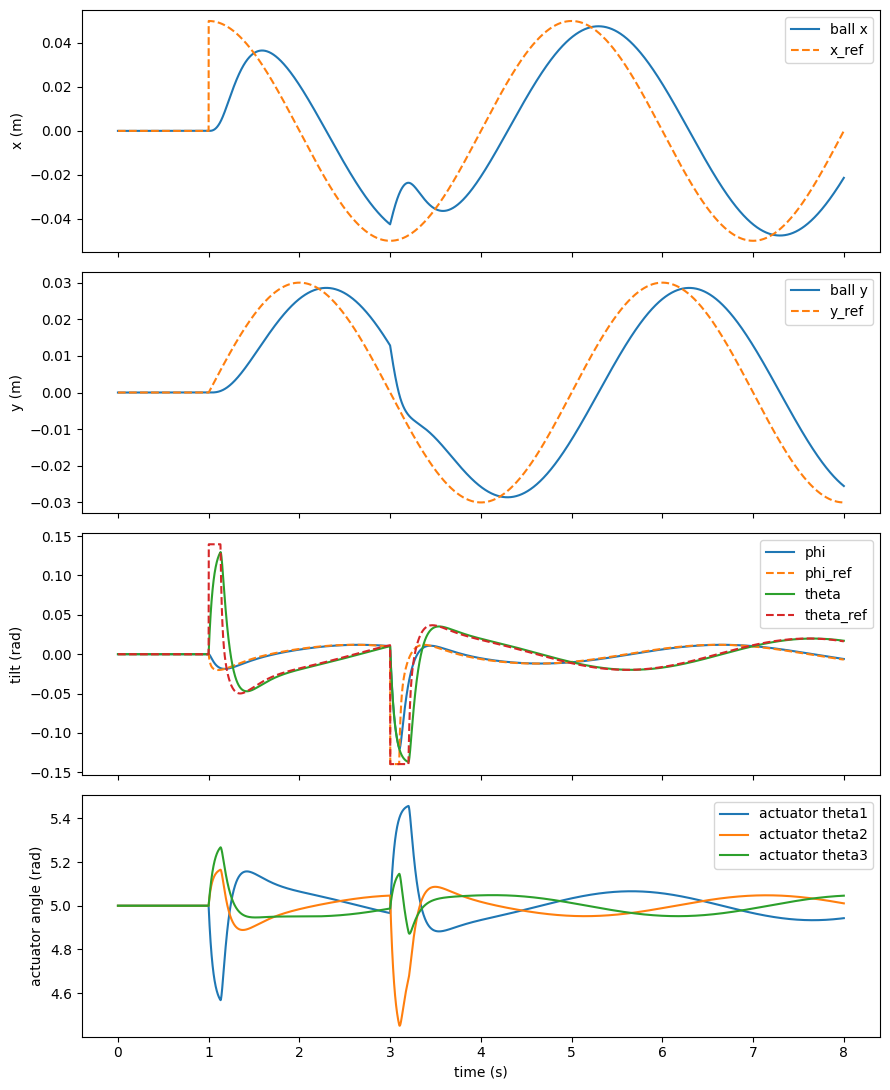

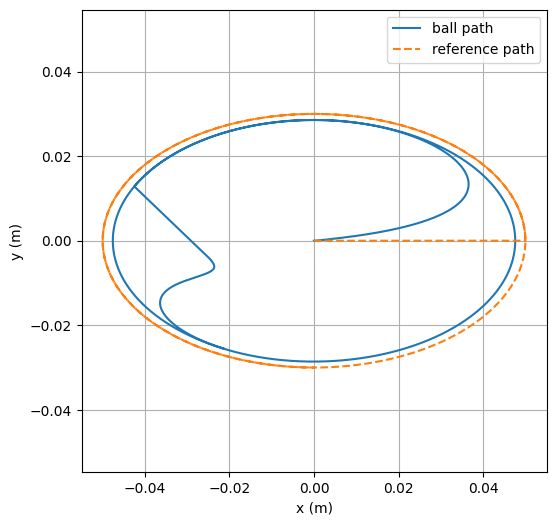

In [ ]:
# pip install numpy scipy control matplotlib
import numpy as np
import matplotlib.pyplot as plt
from control import lqr

# --- 3RRS platform and ball parameters ---
Rp = 0.2
m = 0.05
g = 9.81
kr = 5/7
b = 0.05
Ta = 0.05
actuator_gain = 0.06  # m/rad, linearized support height change per actuator angle

# 3-actuator geometry around the platform
psi = np.array([0, 2*np.pi/3, 4*np.pi/3])
x = Rp * np.cos(psi)
y = Rp * np.sin(psi)
J = np.vstack([y, -x, np.ones(3)]).T
Jinv = np.linalg.inv(J)

# Gain from the separate state-space notebook, kept for reference
K_from_state_space = np.array([[-2375.53715979, 6.83175631, 2693.34213143, 97.1400587]])

# 1-axis outer-loop model; we reuse it independently for x and y motion
A_axis = np.array([
    [0.0, 1.0, 0.0],
    [0.0, -(b / m), kr * g],
    [0.0, 0.0, -(1.0 / Ta)],
])
B_axis = np.array([[0.0], [0.0], [1.0 / Ta]])
Q_axis = np.diag([500.0, 20.0, 10.0])
R_axis = np.array([[1.0]])
K_axis, _, poles_axis = lqr(A_axis, B_axis, Q_axis, R_axis)
K_axis = np.asarray(K_axis)
tilt_limit = np.deg2rad(8.0)

print('K from state_space_lrq =', K_from_state_space)
print('K used per axis in skeleton_simulation =', K_axis)
print('Axis poles =', poles_axis)

# Simulation settings
dt = 0.001
Tsim = 8.0
steps = int(Tsim / dt)
time = np.linspace(0.0, Tsim, steps)

# Initial actuator states: [theta1, theta2, theta3]
theta_act = np.array([5.0, 5.0, 5.0])
theta_act_dot = np.zeros(3)
support_z = actuator_gain * theta_act
phi, theta, h = Jinv.dot(support_z)

# Ball states on the platform surface
x_ball = 0.0
y_ball = 0.0
x_ball_dot = 0.0
y_ball_dot = 0.0

# Reference path: hold, then move on an ellipse
x_ref_log = []
y_ref_log = []

# Logs
log_x = []
log_y = []
log_phi = []
log_theta = []
log_phi_ref = []
log_theta_ref = []
log_theta1 = []
log_theta2 = []
log_theta3 = []

for t in time:
    if t < 1.0:
        x_ref = 0.0
        y_ref = 0.0
    else:
        omega = 2.0 * np.pi / 4.0
        x_ref = 0.05 * np.cos(omega * (t - 1.0))
        y_ref = 0.03 * np.sin(omega * (t - 1.0))

    # Disturbance case: a brief push on the ball velocity
    if abs(t - 3.0) < 0.5 * dt:
        x_ball_dot += 0.20
        y_ball_dot -= 0.12

    # Independent LQR regulators for x and y motion
    state_x = np.array([x_ball - x_ref, x_ball_dot, theta])
    state_y = np.array([y_ball - y_ref, y_ball_dot, -phi])

    theta_ref = float((-K_axis @ state_x.reshape(-1, 1)).item())
    phi_cmd = float((-K_axis @ state_y.reshape(-1, 1)).item())

    theta_ref = np.clip(theta_ref, -tilt_limit, tilt_limit)
    phi_ref = np.clip(-phi_cmd, -tilt_limit, tilt_limit)

    # Desired platform pose p_ref = [phi_ref, theta_ref, h_ref]
    p_ref = np.array([phi_ref, theta_ref, 0.30])

    # Inverse kinematics: desired support heights and actuator angles
    support_z_ref = J.dot(p_ref)
    theta_act_ref = support_z_ref / actuator_gain

    # 3RRS actuator dynamics
    theta_act_dot = -(theta_act - theta_act_ref) / Ta
    theta_act += theta_act_dot * dt

    # Forward kinematics: platform pose from the 3 actuator angles
    support_z = actuator_gain * theta_act
    phi, theta, h = Jinv.dot(support_z)

    # Ball dynamics on the tilted platform
    x_ball_dd = kr * g * theta - (b / m) * x_ball_dot
    y_ball_dd = -kr * g * phi - (b / m) * y_ball_dot
    x_ball_dot += x_ball_dd * dt
    y_ball_dot += y_ball_dd * dt
    x_ball += x_ball_dot * dt
    y_ball += y_ball_dot * dt

    x_ref_log.append(x_ref)
    y_ref_log.append(y_ref)
    log_x.append(x_ball)
    log_y.append(y_ball)
    log_phi.append(phi)
    log_theta.append(theta)
    log_phi_ref.append(phi_ref)
    log_theta_ref.append(theta_ref)
    log_theta1.append(theta_act[0])
    log_theta2.append(theta_act[1])
    log_theta3.append(theta_act[2])

fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

axes[0].plot(time, log_x, label='ball x')
axes[0].plot(time, x_ref_log, '--', label='x_ref')
axes[0].set_ylabel('x (m)')
axes[0].legend()

axes[1].plot(time, log_y, label='ball y')
axes[1].plot(time, y_ref_log, '--', label='y_ref')
axes[1].set_ylabel('y (m)')
axes[1].legend()

axes[2].plot(time, log_phi, label='phi')
axes[2].plot(time, log_phi_ref, '--', label='phi_ref')
axes[2].plot(time, log_theta, label='theta')
axes[2].plot(time, log_theta_ref, '--', label='theta_ref')
axes[2].set_ylabel('tilt (rad)')
axes[2].legend()

axes[3].plot(time, log_theta1, label='actuator theta1')
axes[3].plot(time, log_theta2, label='actuator theta2')
axes[3].plot(time, log_theta3, label='actuator theta3')
axes[3].set_xlabel('time (s)')
axes[3].set_ylabel('actuator angle (rad)')
axes[3].legend()

plt.tight_layout()
plt.figure(figsize=(6, 6))
plt.plot(log_x, log_y, label='ball path')
plt.plot(x_ref_log, y_ref_log, '--', label='reference path')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


## 15. Tuning Cell: ลด lag และ overshoot ของ path tracking

Cell นี้ใช้เปรียบเทียบ `baseline` กับ `tuned controller` โดยแยกให้เห็นชัดว่าอะไรทำให้ tracking ดีขึ้น
แนวทางที่ใช้มี 2 ส่วน
1. ปรับน้ำหนักของ LQR ให้ตอบสนองต่อ position/velocity error เร็วขึ้น
2. ทำให้ reference path เริ่มต้นแบบ smooth แทนการกระโดดทันทีที่เวลา 1 วินาที ซึ่งช่วยลด overshoot ตอนเริ่มตามพาธได้มาก

ตัวชี้วัดที่พิมพ์ออกมาคือ
- `RMSE after 1 s` : ค่าคลาดเคลื่อนเฉลี่ยหลังเริ่มตามพาธ
- `Peak error after 1 s` : ค่าคลาดเคลื่อนสูงสุดหลังเริ่มตามพาธ

Baseline K = [[22.3607  6.1893  2.9162]]
Tuned K    = [[28.2843  7.6712  3.2866]]
Baseline RMSE after 1 s = 0.02003
Tuned RMSE after 1 s    = 0.01753
Baseline peak error after 1 s = 0.05
Tuned peak error after 1 s    = 0.02427


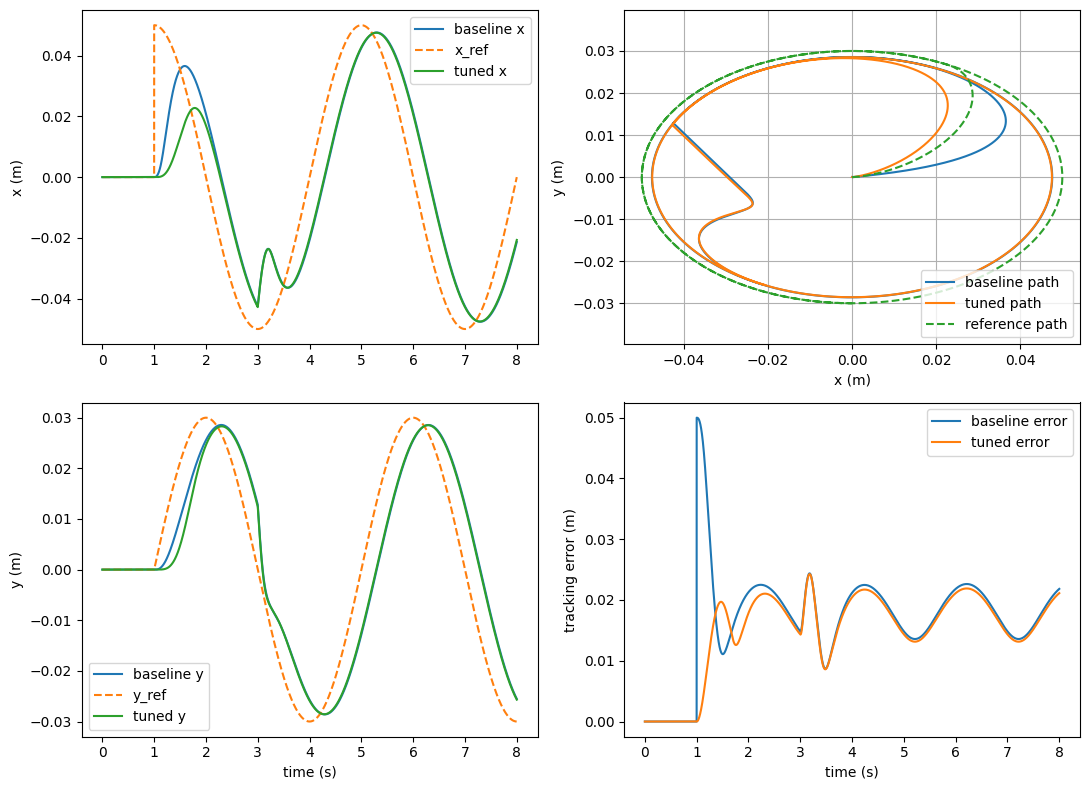

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from control import lqr

# Parameters reused from the main 3RRS example
Rp = 0.2
m = 0.05
g = 9.81
kr = 5/7
b = 0.05
Ta = 0.05
actuator_gain = 0.06
psi = np.array([0, 2*np.pi/3, 4*np.pi/3])
J = np.vstack([Rp * np.sin(psi), -Rp * np.cos(psi), np.ones(3)]).T
Jinv = np.linalg.inv(J)

def smoothstep01(value):
    value = np.clip(value, 0.0, 1.0)
    return value * value * (3.0 - 2.0 * value)

def simulate_tracking(Q_diag, R_value, smooth_reference=False, tilt_deg=8.0):
    A_axis = np.array([
        [0.0, 1.0, 0.0],
        [0.0, -(b / m), kr * g],
        [0.0, 0.0, -(1.0 / Ta)],
    ])
    B_axis = np.array([[0.0], [0.0], [1.0 / Ta]])
    K_axis, _, _ = lqr(A_axis, B_axis, np.diag(Q_diag), np.array([[R_value]]))
    K_axis = np.asarray(K_axis)
    tilt_limit = np.deg2rad(tilt_deg)

    dt = 0.001
    Tsim = 8.0
    time = np.linspace(0.0, Tsim, int(Tsim / dt))

    theta_act = np.array([5.0, 5.0, 5.0])
    phi, theta, h = Jinv.dot(actuator_gain * theta_act)
    x_ball = 0.0
    y_ball = 0.0
    x_ball_dot = 0.0
    y_ball_dot = 0.0

    log_x = []
    log_y = []
    log_err = []
    x_ref_log = []
    y_ref_log = []

    for t in time:
        if t < 1.0:
            x_ref = 0.0
            y_ref = 0.0
        else:
            omega = 2.0 * np.pi / 4.0
            blend = 1.0
            if smooth_reference:
                blend = smoothstep01((t - 1.0) / 0.7)
            x_ref = blend * 0.05 * np.cos(omega * (t - 1.0))
            y_ref = blend * 0.03 * np.sin(omega * (t - 1.0))

        if abs(t - 3.0) < 0.5 * dt:
            x_ball_dot += 0.20
            y_ball_dot -= 0.12

        state_x = np.array([x_ball - x_ref, x_ball_dot, theta])
        state_y = np.array([y_ball - y_ref, y_ball_dot, -phi])

        theta_ref = float((-K_axis @ state_x.reshape(-1, 1)).item())
        phi_cmd = float((-K_axis @ state_y.reshape(-1, 1)).item())

        theta_ref = np.clip(theta_ref, -tilt_limit, tilt_limit)
        phi_ref = np.clip(-phi_cmd, -tilt_limit, tilt_limit)

        p_ref = np.array([phi_ref, theta_ref, 0.30])
        theta_act_ref = J.dot(p_ref) / actuator_gain
        theta_act_dot = -(theta_act - theta_act_ref) / Ta
        theta_act += theta_act_dot * dt

        phi, theta, h = Jinv.dot(actuator_gain * theta_act)

        x_ball_dd = kr * g * theta - (b / m) * x_ball_dot
        y_ball_dd = -kr * g * phi - (b / m) * y_ball_dot
        x_ball_dot += x_ball_dd * dt
        y_ball_dot += y_ball_dd * dt
        x_ball += x_ball_dot * dt
        y_ball += y_ball_dot * dt

        tracking_error = np.hypot(x_ball - x_ref, y_ball - y_ref)
        log_x.append(x_ball)
        log_y.append(y_ball)
        log_err.append(tracking_error)
        x_ref_log.append(x_ref)
        y_ref_log.append(y_ref)

    steady_slice = time >= 1.0
    rmse = float(np.sqrt(np.mean(np.square(np.asarray(log_err)[steady_slice]))))
    peak_error = float(np.max(np.asarray(log_err)[steady_slice]))

    return {
        'time': time,
        'x': np.asarray(log_x),
        'y': np.asarray(log_y),
        'err': np.asarray(log_err),
        'x_ref': np.asarray(x_ref_log),
        'y_ref': np.asarray(y_ref_log),
        'rmse': rmse,
        'peak_error': peak_error,
        'K': K_axis,
    }

baseline = simulate_tracking(Q_diag=[500.0, 20.0, 10.0], R_value=1.0, smooth_reference=False)
tuned = simulate_tracking(Q_diag=[1200.0, 50.0, 18.0], R_value=1.5, smooth_reference=True)

print('Baseline K =', np.round(baseline['K'], 4))
print('Tuned K    =', np.round(tuned['K'], 4))
print('Baseline RMSE after 1 s =', round(baseline['rmse'], 5))
print('Tuned RMSE after 1 s    =', round(tuned['rmse'], 5))
print('Baseline peak error after 1 s =', round(baseline['peak_error'], 5))
print('Tuned peak error after 1 s    =', round(tuned['peak_error'], 5))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(baseline['time'], baseline['x'], label='baseline x')
axes[0, 0].plot(baseline['time'], baseline['x_ref'], '--', label='x_ref')
axes[0, 0].plot(tuned['time'], tuned['x'], label='tuned x')
axes[0, 0].set_ylabel('x (m)')
axes[0, 0].legend()

axes[1, 0].plot(baseline['time'], baseline['y'], label='baseline y')
axes[1, 0].plot(baseline['time'], baseline['y_ref'], '--', label='y_ref')
axes[1, 0].plot(tuned['time'], tuned['y'], label='tuned y')
axes[1, 0].set_xlabel('time (s)')
axes[1, 0].set_ylabel('y (m)')
axes[1, 0].legend()

axes[0, 1].plot(baseline['x'], baseline['y'], label='baseline path')
axes[0, 1].plot(tuned['x'], tuned['y'], label='tuned path')
axes[0, 1].plot(tuned['x_ref'], tuned['y_ref'], '--', label='reference path')
axes[0, 1].set_xlabel('x (m)')
axes[0, 1].set_ylabel('y (m)')
axes[0, 1].axis('equal')
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 1].plot(baseline['time'], baseline['err'], label='baseline error')
axes[1, 1].plot(tuned['time'], tuned['err'], label='tuned error')
axes[1, 1].set_xlabel('time (s)')
axes[1, 1].set_ylabel('tracking error (m)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 16. Bounce/Catch Mode Cell

Cell นี้ปรับให้มองเห็นการเดาะของลูกอย่างชัดเจน `10 ครั้ง` ก่อนเข้าสู่โหมดรับลูก (`hold`)
แนวคิดที่ใช้คือ
- ช่วง `bounce mode` ใช้โมเดลกระแทกแบบ event-based
- ทุกครั้งที่ลูกชนแท่น จะเกิดการสะท้อนกลับด้วยค่าสัมประสิทธิ์การคืนตัว (`coefficient of restitution`)
- ตัวแปร `target_bounces = 10` ใช้กำหนดจำนวนครั้งที่ต้องการเห็นการเดาะ
- เมื่อครบ 10 ครั้ง ระบบจะเปลี่ยนเป็น `hold mode` เพื่อให้ลูกหยุดนิ่งบนแพลตฟอร์ม

โมเดลนี้เหมาะสำหรับการสาธิตพฤติกรรมเดาะหลายครั้งให้เห็นชัดเจนกว่าการใช้ contact damping อย่างเดียว

Bounce count = 10
Impact times (s) = [0.141 0.633 1.065 1.444 1.777 2.069 2.325 2.55  2.747 2.919]
Final ball-platform gap = 0.0 m
Final ball vertical velocity = 0.00997 m/s
Final platform vertical velocity = 0.00997 m/s
Max impact force estimate = 137.151 N


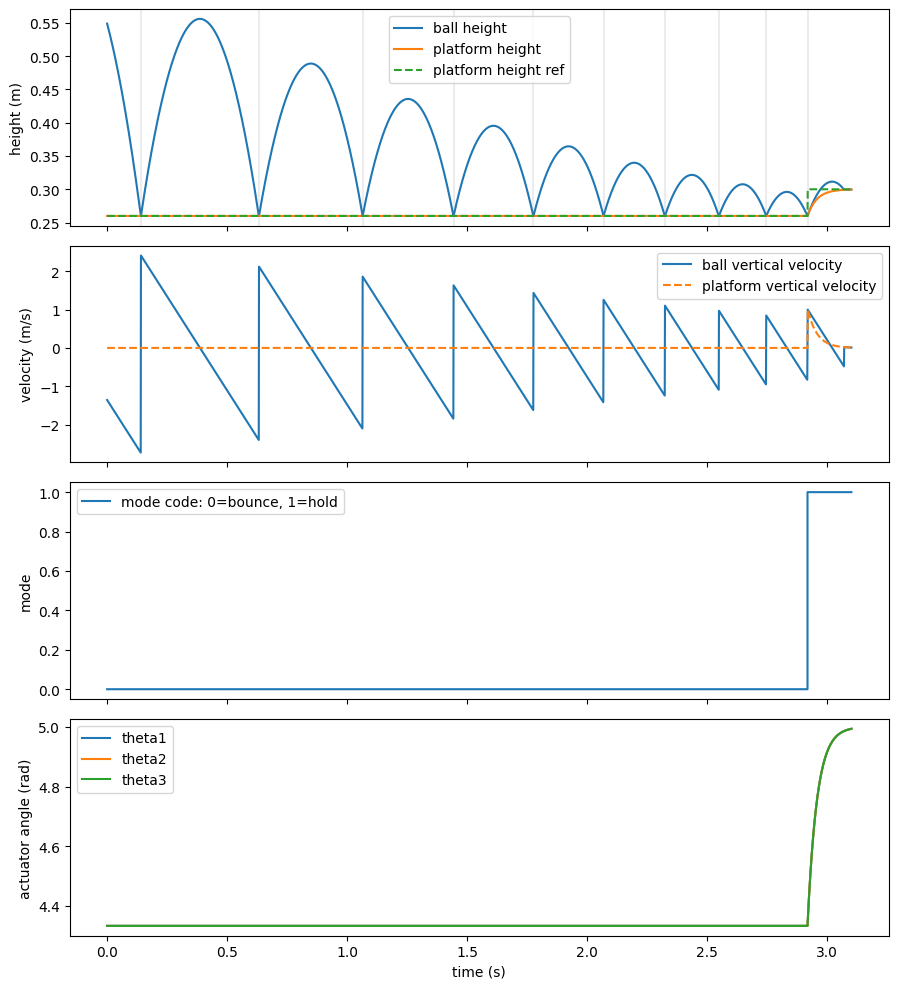

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Event-based bounce/catch model for the same 3RRS platform
m = 0.05
g = 9.81
Ta = 0.04
actuator_gain = 0.06

# Bounce/catch settings
target_bounces = 10
restitution = 0.88
h_bounce = 0.26
h_hold = 0.30

dt = 0.001
Tsim = 6.0
time = np.linspace(0.0, Tsim, int(Tsim / dt))

# Pure vertical motion: all 3 actuators move together
theta_act = np.ones(3) * (h_bounce / actuator_gain)
theta_act_dot = np.zeros(3)

# Ball initial condition: dropped from above the platform
z_ball = 0.55
z_ball_dot = -1.35

mode = 'bounce'
bounce_count = 0
max_impact_force = 0.0

log_time = []
log_z_ball = []
log_z_ball_dot = []
log_h = []
log_h_dot = []
log_h_ref = []
log_theta1 = []
log_theta2 = []
log_theta3 = []
log_mode = []
impact_times = []

for t in time:
    h = actuator_gain * np.mean(theta_act)

    if mode == 'bounce':
        h_ref = h_bounce
    else:
        h_ref = h_hold

    theta_act_ref = np.ones(3) * (h_ref / actuator_gain)
    theta_act_dot = -(theta_act - theta_act_ref) / Ta
    theta_act += theta_act_dot * dt

    h_next = actuator_gain * np.mean(theta_act)
    h_dot = (h_next - h) / dt
    h = h_next

    # Free-flight update
    z_ball_dot += -g * dt
    z_ball += z_ball_dot * dt

    # Discrete impact event with restitution; the 10th impact is captured
    if mode == 'bounce' and z_ball <= h and z_ball_dot < h_dot:
        relative_velocity_before = z_ball_dot - h_dot
        max_impact_force = max(max_impact_force, m * abs(relative_velocity_before) / dt)
        z_ball = h
        bounce_count += 1
        impact_times.append(t)

        if bounce_count >= target_bounces:
            mode = 'hold'
            z_ball_dot = h_dot
        else:
            z_ball_dot = h_dot - restitution * relative_velocity_before

    elif mode == 'hold':
        if z_ball <= h and z_ball_dot < h_dot:
            z_ball = h
            z_ball_dot = h_dot

    log_time.append(t)
    log_z_ball.append(z_ball)
    log_z_ball_dot.append(z_ball_dot)
    log_h.append(h)
    log_h_dot.append(h_dot)
    log_h_ref.append(h_ref)
    log_theta1.append(theta_act[0])
    log_theta2.append(theta_act[1])
    log_theta3.append(theta_act[2])
    log_mode.append({'bounce': 0, 'hold': 1}[mode])

    if mode == 'hold' and abs(h - h_hold) < 1e-3 and abs(h_dot) < 1e-2 and abs(z_ball - h) < 1e-4 and abs(z_ball_dot) < 1e-2:
        break

print('Bounce count =', bounce_count)
print('Impact times (s) =', np.round(impact_times, 3))
print('Final ball-platform gap =', round(log_z_ball[-1] - log_h[-1], 5), 'm')
print('Final ball vertical velocity =', round(log_z_ball_dot[-1], 5), 'm/s')
print('Final platform vertical velocity =', round(log_h_dot[-1], 5), 'm/s')
print('Max impact force estimate =', round(max_impact_force, 3), 'N')

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(log_time, log_z_ball, label='ball height')
axes[0].plot(log_time, log_h, label='platform height')
axes[0].plot(log_time, log_h_ref, '--', label='platform height ref')
for impact_time in impact_times:
    axes[0].axvline(impact_time, color='gray', alpha=0.15)
axes[0].set_ylabel('height (m)')
axes[0].legend()

axes[1].plot(log_time, log_z_ball_dot, label='ball vertical velocity')
axes[1].plot(log_time, log_h_dot, '--', label='platform vertical velocity')
axes[1].set_ylabel('velocity (m/s)')
axes[1].legend()

axes[2].step(log_time, log_mode, where='post', label='mode code: 0=bounce, 1=hold')
axes[2].set_ylabel('mode')
axes[2].legend()

axes[3].plot(log_time, log_theta1, label='theta1')
axes[3].plot(log_time, log_theta2, label='theta2')
axes[3].plot(log_time, log_theta3, label='theta3')
axes[3].set_xlabel('time (s)')
axes[3].set_ylabel('actuator angle (rad)')
axes[3].legend()

plt.tight_layout()
plt.show()

## 17. Restitution Comparison Cell

Cell นี้เปรียบเทียบกรณี `มี coefficient of restitution` กับ `ไม่มี coefficient of restitution` โดยใช้โมเดลเดาะแนวตั้งแบบเดียวกัน
- กรณี `with restitution` ลูกจะสะท้อนกลับหลายครั้งก่อนถูกจับ
- กรณี `without restitution` ลูกจะไม่เด้งกลับหลังชน และเข้าสู่การรับลูกทันที
- การเปรียบเทียบนี้ช่วยให้เห็นชัดว่า restitution มีผลต่อรูปกราฟความสูงและความเร็วอย่างไร

With restitution: bounce_count = 10
Without restitution: bounce_count = 1


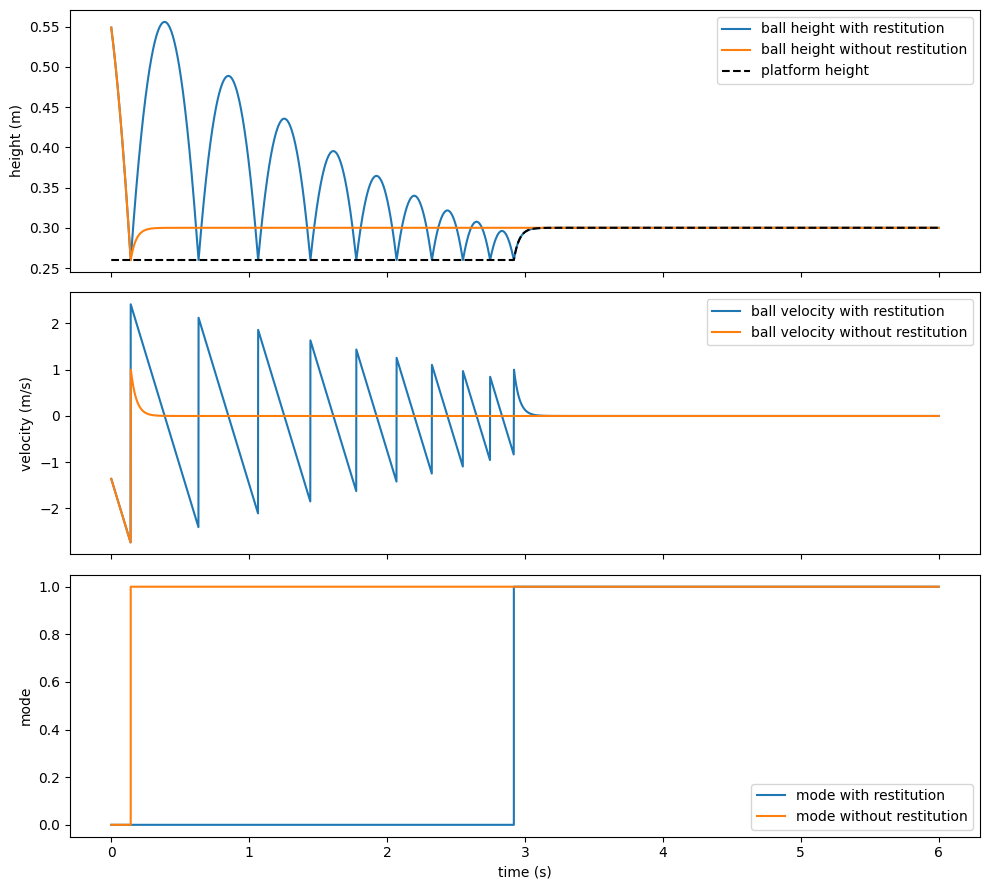

In [15]:
import numpy as np
import matplotlib.pyplot as plt

m = 0.05
g = 9.81
Ta = 0.04
actuator_gain = 0.06
h_bounce = 0.26
h_hold = 0.30
dt = 0.001
Tsim = 6.0

def simulate_bounce_case(restitution, target_bounces=10):
    time = np.linspace(0.0, Tsim, int(Tsim / dt))
    theta_act = np.ones(3) * (h_bounce / actuator_gain)
    z_ball = 0.55
    z_ball_dot = -1.35
    mode = 'bounce'
    bounce_count = 0
    impact_times = []
    log_time = []
    log_z_ball = []
    log_z_ball_dot = []
    log_h = []
    log_mode = []

    for t in time:
        h = actuator_gain * np.mean(theta_act)
        h_ref = h_bounce if mode == 'bounce' else h_hold
        theta_act_ref = np.ones(3) * (h_ref / actuator_gain)
        theta_act += (-(theta_act - theta_act_ref) / Ta) * dt
        h_next = actuator_gain * np.mean(theta_act)
        h_dot = (h_next - h) / dt
        h = h_next

        if mode == 'bounce':
            z_ball_dot += -g * dt
            z_ball += z_ball_dot * dt

            if z_ball <= h and z_ball_dot < h_dot:
                rel_before = z_ball_dot - h_dot
                z_ball = h
                bounce_count += 1
                impact_times.append(t)

                if restitution <= 0.0 or bounce_count >= target_bounces:
                    mode = 'hold'
                    z_ball_dot = h_dot
                else:
                    z_ball_dot = h_dot - restitution * rel_before
        else:
            z_ball = h
            z_ball_dot = h_dot

        log_time.append(t)
        log_z_ball.append(z_ball)
        log_z_ball_dot.append(z_ball_dot)
        log_h.append(h)
        log_mode.append({'bounce': 0, 'hold': 1}[mode])

    return {
        'time': np.asarray(log_time),
        'z_ball': np.asarray(log_z_ball),
        'z_ball_dot': np.asarray(log_z_ball_dot),
        'h': np.asarray(log_h),
        'mode': np.asarray(log_mode),
        'impact_times': impact_times,
        'bounce_count': bounce_count,
    }

case_with_restitution = simulate_bounce_case(restitution=0.88, target_bounces=10)
case_without_restitution = simulate_bounce_case(restitution=0.0, target_bounces=10)

print('With restitution: bounce_count =', case_with_restitution['bounce_count'])
print('Without restitution: bounce_count =', case_without_restitution['bounce_count'])

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(case_with_restitution['time'], case_with_restitution['z_ball'], label='ball height with restitution')
axes[0].plot(case_without_restitution['time'], case_without_restitution['z_ball'], label='ball height without restitution')
axes[0].plot(case_with_restitution['time'], case_with_restitution['h'], '--', color='black', label='platform height')
axes[0].set_ylabel('height (m)')
axes[0].legend()

axes[1].plot(case_with_restitution['time'], case_with_restitution['z_ball_dot'], label='ball velocity with restitution')
axes[1].plot(case_without_restitution['time'], case_without_restitution['z_ball_dot'], label='ball velocity without restitution')
axes[1].set_ylabel('velocity (m/s)')
axes[1].legend()

axes[2].step(case_with_restitution['time'], case_with_restitution['mode'], where='post', label='mode with restitution')
axes[2].step(case_without_restitution['time'], case_without_restitution['mode'], where='post', label='mode without restitution')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('mode')
axes[2].legend()

plt.tight_layout()
plt.show()

## 18. Impact Sequence Cell

Cell นี้โฟกัสเฉพาะลำดับการกระทบ `1 ถึง 10` ของกรณีที่มี restitution
มีการใส่หมายเลข bounce ลงบนกราฟเพื่อให้เห็นว่าแต่ละ impact เกิดเมื่อใด และช่วงเวลาระหว่างการเดาะค่อย ๆ สั้นลงหรือยาวขึ้นอย่างไร

Impact count = 10
Impact times (s) = [0.141 0.633 1.065 1.444 1.777 2.069 2.325 2.55  2.747 2.919]


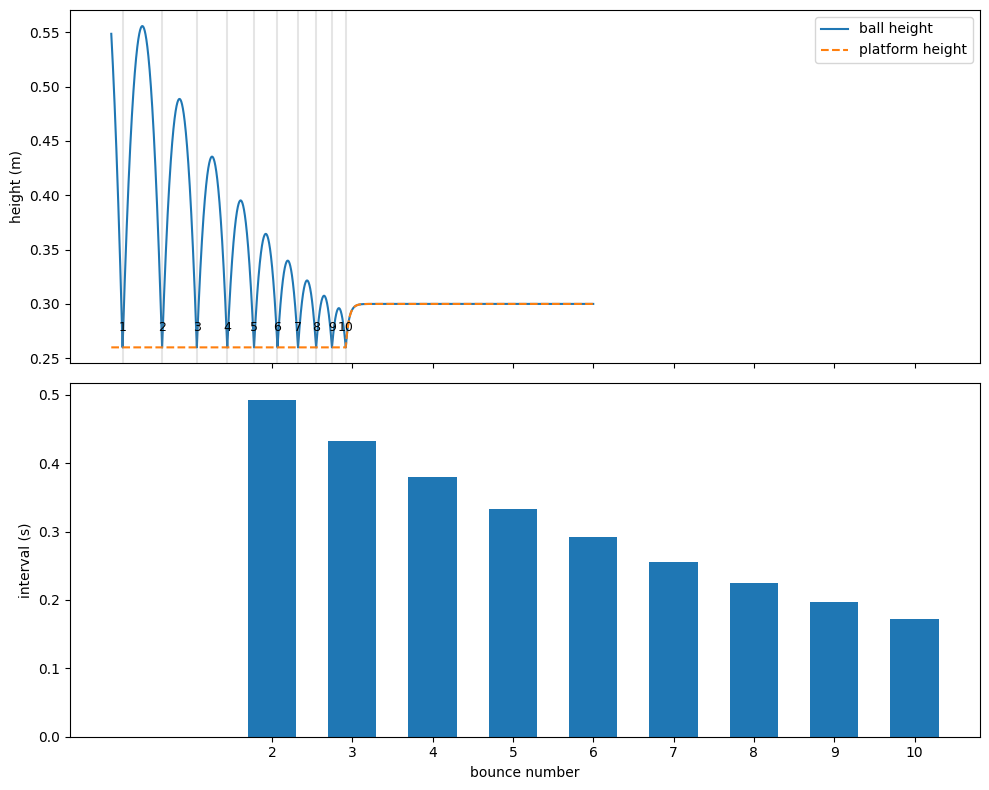

In [16]:
import numpy as np
import matplotlib.pyplot as plt

m = 0.05
g = 9.81
Ta = 0.04
actuator_gain = 0.06
h_bounce = 0.26
h_hold = 0.30
dt = 0.001
Tsim = 6.0
target_bounces = 10
restitution = 0.88

time = np.linspace(0.0, Tsim, int(Tsim / dt))
theta_act = np.ones(3) * (h_bounce / actuator_gain)
z_ball = 0.55
z_ball_dot = -1.35
mode = 'bounce'
impact_times = []
impact_heights = []
log_time = []
log_z_ball = []
log_h = []

for t in time:
    h = actuator_gain * np.mean(theta_act)
    h_ref = h_bounce if mode == 'bounce' else h_hold
    theta_act_ref = np.ones(3) * (h_ref / actuator_gain)
    theta_act += (-(theta_act - theta_act_ref) / Ta) * dt
    h_next = actuator_gain * np.mean(theta_act)
    h_dot = (h_next - h) / dt
    h = h_next

    if mode == 'bounce':
        z_ball_dot += -g * dt
        z_ball += z_ball_dot * dt

        if z_ball <= h and z_ball_dot < h_dot:
            rel_before = z_ball_dot - h_dot
            z_ball = h
            impact_times.append(t)
            impact_heights.append(h)

            if len(impact_times) >= target_bounces:
                mode = 'hold'
                z_ball_dot = h_dot
            else:
                z_ball_dot = h_dot - restitution * rel_before
    else:
        z_ball = h
        z_ball_dot = h_dot

    log_time.append(t)
    log_z_ball.append(z_ball)
    log_h.append(h)

print('Impact count =', len(impact_times))
print('Impact times (s) =', np.round(impact_times, 3))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(log_time, log_z_ball, label='ball height')
axes[0].plot(log_time, log_h, '--', label='platform height')
for index, impact_time in enumerate(impact_times, start=1):
    axes[0].axvline(impact_time, color='gray', alpha=0.2)
    axes[0].text(impact_time, impact_heights[index - 1] + 0.012, str(index), ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('height (m)')
axes[0].legend()

if len(impact_times) > 1:
    intervals = np.diff(impact_times)
    axes[1].bar(np.arange(2, len(impact_times) + 1), intervals, width=0.6)
    axes[1].set_ylabel('interval (s)')
    axes[1].set_xlabel('bounce number')
    axes[1].set_xticks(np.arange(2, len(impact_times) + 1))
else:
    axes[1].text(0.5, 0.5, 'Not enough impacts for interval plot', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_xlabel('bounce number')

plt.tight_layout()
plt.show()